<a href="https://colab.research.google.com/github/tinoe0404/cartify/blob/main/AI_Practical_Test_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Practical Test 1 — Chest X-Ray Pneumonia Classification
**Student:** CHIDEWE MARION T  
**Reg Number:** H220009A  
**Institution:** HIT  
**Date:** May 2026

---
## Setup — Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install tensorflow scikit-learn matplotlib numpy opencv-python seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')
print('All libraries loaded successfully.')

TensorFlow version: 2.20.0
All libraries loaded successfully.


In [2]:
# ============================================================
# COLAB SETUP: Download dataset from Kaggle
# ============================================================

import os
if os.path.exists('/content'):
    print('Running on Google Colab...')

    # Paste your Kaggle API token below:
    os.environ['KAGGLE_API_TOKEN'] = 'KGAT_4aecc35c9588607691459b18810145a'

    if not os.path.exists('/content/chest_xray'):
        !pip install -q kaggle
        !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/
        !unzip -q /content/chest-xray-pneumonia.zip -d /content/
        print('Dataset ready!')
    else:
        print('Dataset already exists.')
else:
    print('Not on Colab. Make sure dataset is at BASE_DIR.')


Running on Google Colab...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 130MB/s] 

Dataset ready!


---
## Question 1: Problem Definition (5 Marks)

### 1.1 Problem Definition (In My Own Words)

Pneumonia is a serious lung infection that causes the air sacs in one or both lungs to fill with fluid or pus. Diagnosing pneumonia typically requires a radiographer or radiologist to examine a chest X-ray and determine whether the lung tissue shows signs of infection. However, this process can be slow, prone to human error, and is heavily reliant on the availability of skilled professionals — a challenge in resource-constrained environments like Zimbabwe.

**The problem:** Can a machine learning model automatically classify chest X-ray images as either NORMAL or PNEUMONIA with high accuracy, reducing the burden on radiographers and speeding up clinical diagnosis?

### 1.2 Type of Machine Learning Problem

This is a **Binary Image Classification** problem — a supervised learning task where the model learns from labelled X-ray images to predict one of two classes:
- **Class 0:** NORMAL (healthy lungs)
- **Class 1:** PNEUMONIA (infected lungs)

### 1.3 Relevance to Radiography Practice

- **Speed:** Automated classification provides an instant preliminary read, allowing radiographers to prioritise urgent cases faster.
- **Consistency:** ML models apply the same criteria every time, unlike human readers who may be affected by fatigue or experience level.
- **Triage support:** In hospitals with high patient loads, the model can flag high-risk cases for immediate expert review.
- **Low-resource settings:** In areas with few radiologists, such a tool can serve as a decision-support aid for general practitioners reviewing X-rays.
- **Training tool:** Can be used to train radiography students by comparing their reads against model output.

---
## Question 2: Data Understanding & Preparation (10 Marks)

### 2.1 Dataset Description

| Property | Details |
|---|---|
| **Source** | Kaggle — Chest X-Ray Images (Pneumonia) |
| **Total Images** | 5,863 JPEG X-ray images |
| **Classes** | 2 — NORMAL and PNEUMONIA |
| **Training set** | 5,216 images (NORMAL: 1,341 / PNEUMONIA: 3,875) |
| **Test set** | 624 images (NORMAL: 234 / PNEUMONIA: 390) |
| **Image format** | Grayscale chest X-rays (anterior-posterior view) |
| **Image size** | Variable — resized to 150×150 pixels for training |

**Note:** The dataset is imbalanced — pneumonia cases are roughly 3x more than normal cases. This is clinically realistic (hospitals see more sick patients) but must be considered during evaluation.

In [3]:
# ============================================================
# DATASET LOADING
# After downloading from Kaggle, set your path below:
# ============================================================
# Auto-detect Colab vs local
import os
if os.path.exists('/content/chest_xray'):
    BASE_DIR = '/content/chest_xray'
else:
    BASE_DIR = './chest_xray'  # Update this for local

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
VAL_DIR   = os.path.join(BASE_DIR, 'val')

IMG_SIZE   = 150   # Resize all images to 150x150
BATCH_SIZE = 32

def load_images(folder, img_size=IMG_SIZE):
    """Load images from class subfolders and return arrays."""
    X, y = [], []
    classes = sorted(os.listdir(folder))
    for label, cls in enumerate(classes):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            img   = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), classes

print('Loading training images...')
X_train_raw, y_train_raw, class_names = load_images(TRAIN_DIR)
print(f'Training images loaded: {X_train_raw.shape}')

print('Loading test images...')
X_test_raw, y_test_raw, _ = load_images(TEST_DIR)
print(f'Test images loaded: {X_test_raw.shape}')

print(f'Classes: {class_names}')

Loading training images...
Training images loaded: (5216, 150, 150)
Loading test images...
Test images loaded: (624, 150, 150)
Classes: ['NORMAL', 'PNEUMONIA']


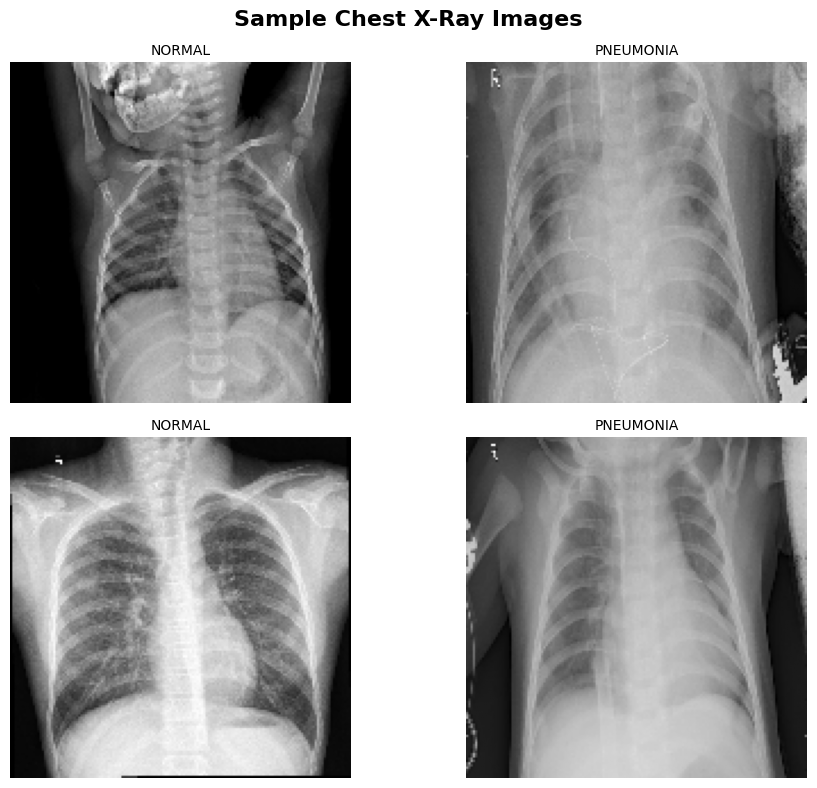

Sample images displayed.


In [4]:
# ---- Visualise sample images from each class ----
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Sample Chest X-Ray Images", fontsize=16, fontweight="bold")

for col, cls in enumerate(class_names):
    idx = np.where(y_train_raw == col)[0][:2]
    for row, i in enumerate(idx):
        axes[row][col].imshow(X_train_raw[i], cmap="gray")
        axes[row][col].set_title(cls, fontsize=10)
        axes[row][col].axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=100)
plt.show()
print("Sample images displayed.")

Training class distribution:
  NORMAL: 1341 images (25.7%)
  PNEUMONIA: 3875 images (74.3%)


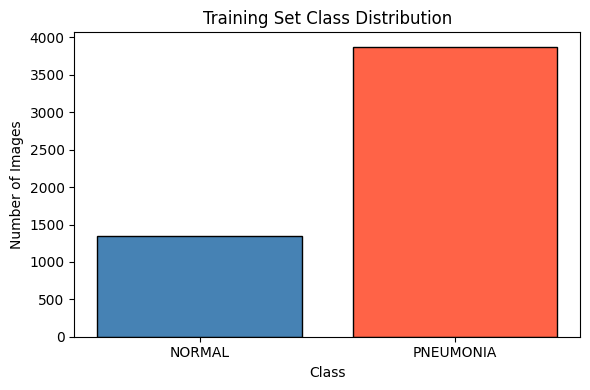

In [5]:
# ---- Class distribution ----
unique, counts = np.unique(y_train_raw, return_counts=True)
print('Training class distribution:')
for u, c in zip(unique, counts):
    print(f'  {class_names[u]}: {c} images ({c/len(y_train_raw)*100:.1f}%)')

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Training Set Class Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Class')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

### 2.2 Pre-processing Steps

In [6]:
# ---- Pre-processing: Normalise pixel values to [0, 1] ----
# Images are grayscale, pixel values range from 0–255.
# Normalising to 0–1 speeds up training and improves convergence.

X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

# Reshape for CNN input: (samples, height, width, channels)
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test  = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

y_train = y_train_raw
y_test  = y_test_raw

print(f'X_train shape: {X_train.shape} | dtype: {X_train.dtype}')
print(f'X_test  shape: {X_test.shape}  | dtype: {X_test.dtype}')
print(f'Pixel range after normalisation: [{X_train.min():.2f}, {X_train.max():.2f}]')

X_train shape: (5216, 150, 150, 1) | dtype: float32
X_test  shape: (624, 150, 150, 1)  | dtype: float32
Pixel range after normalisation: [0.00, 1.00]


### 2.3 Why Pre-processing Is Necessary

| Pre-processing Step | Why It's Needed |
|---|---|
| **Resizing to 150×150** | Raw X-ray images vary in size. A fixed input dimension is required by neural networks. |
| **Grayscale loading** | Chest X-rays are inherently grayscale. Removing unnecessary colour channels reduces memory and computation. |
| **Normalisation (÷255)** | Raw pixel values (0–255) are large. Scaling to [0,1] prevents large gradients during backpropagation and speeds up model convergence. |
| **Reshaping (adding channel dim)** | Keras CNN layers expect input in the format (height, width, channels). We add a channel dimension of 1 for grayscale. |

Without these steps, the model would either fail to run, train extremely slowly, or produce poor accuracy due to inconsistent input formats.

---
## Question 3: Model Development (15 Marks)

### 3.1 Model Choice — Simple Convolutional Neural Network (CNN)

**Justification:**
- Chest X-rays are images. CNNs are specifically designed to learn spatial features (edges, textures, shapes) from images through convolutional filters — making them the most appropriate model for this task.
- Logistic Regression and Decision Trees work on flat feature vectors and cannot capture the spatial structure of X-ray images without extensive feature engineering.
- A simple CNN (3 conv layers) is sufficient for binary classification on 150×150 images and avoids overfitting on a ~5,000 image dataset.
- CNNs have been widely validated in medical imaging literature for pneumonia detection specifically.

In [7]:
# ============================================================
# BUILD THE CNN MODEL
# ============================================================

def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    model = models.Sequential(name='Pneumonia_CNN')

    # --- Block 1: Extract low-level features (edges) ---
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- Block 2: Extract mid-level features (textures) ---
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- Block 3: Extract high-level features (lung patterns) ---
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- Flatten & Classify ---
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))          # Prevent overfitting
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # Binary output

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

Model: "Pneumonia_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,827,905 (18.42 MB)

 Trainable params: 4,827,905 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ============================================================
# TRAIN THE MODEL
# ============================================================

# Early stopping: stop if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print('Training model...')
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=BATCH_SIZE,
    validation_split=0.15,   # Use 15% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining complete.')

Training model...
Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.8716 - loss: 0.2898 - val_accuracy: 0.9579 - val_loss: 0.0946
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9589 - loss: 0.1153 - val_accuracy: 0.9974 - val_loss: 0.0109
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9698 - loss: 0.0894 - val_accuracy: 0.9834 - val_loss: 0.0433
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9677 - loss: 0.0925 - val_accuracy: 0.9604 - val_loss: 0.1194
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9747 - loss: 0.0692 - val_accuracy: 0.9898 - val_loss: 0.0245

Training complete.


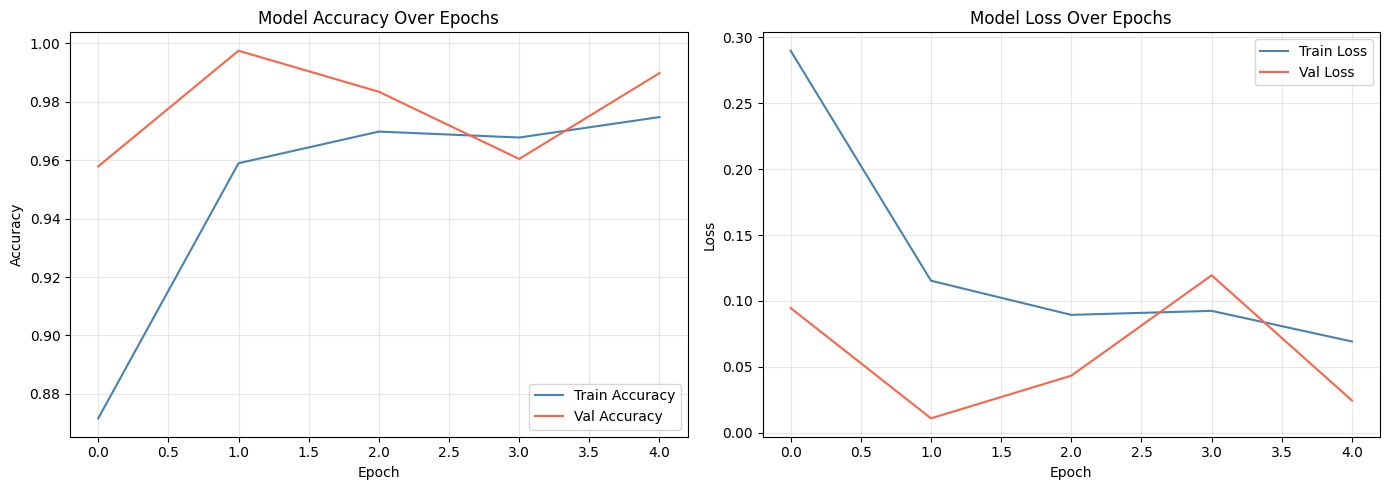

In [9]:
# ---- Plot Training History ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100)
plt.show()

---
## Question 4: Model Evaluation (10 Marks)

In [10]:
# ============================================================
# EVALUATE ON TEST SET
# ============================================================

# Raw predictions (probabilities)
y_pred_prob = model.predict(X_test, verbose=0)

# Convert to binary labels (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

Test Accuracy : 72.92%
Test Loss     : 1.2114


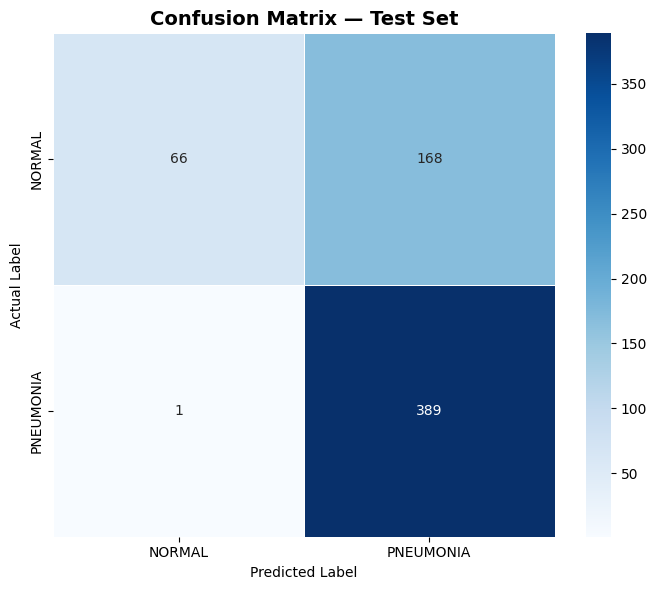


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.28      0.44       234
   PNEUMONIA       0.70      1.00      0.82       390

    accuracy                           0.73       624
   macro avg       0.84      0.64      0.63       624
weighted avg       0.81      0.73      0.68       624



In [11]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

# Print classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

### 4.1 Interpretation of Results

**Reading the Confusion Matrix:**

| | Predicted NORMAL | Predicted PNEUMONIA |
|---|---|---|
| **Actual NORMAL** | True Negatives (TN) | False Positives (FP) |
| **Actual PNEUMONIA** | False Negatives (FN) | True Positives (TP) |

**What errors is the model making?**
- **False Positives (FP):** The model predicts PNEUMONIA for a patient who is actually NORMAL. This causes unnecessary anxiety and follow-up tests, but is medically less dangerous.
- **False Negatives (FN):** The model predicts NORMAL for a patient who actually has PNEUMONIA. This is the more dangerous error — a missed diagnosis could delay treatment and worsen patient outcomes.

**Clinical Implications:**
- In a clinical setting, **minimising False Negatives is critical**. Missing a pneumonia case can be life-threatening, especially in vulnerable patients (children, elderly, immunocompromised).
- A radiographer should therefore use the model as a **screening tool** — cases flagged as NORMAL by the model should still be reviewed if the patient presents with strong symptoms.
- The **Recall score for PNEUMONIA** is the most clinically important metric here (what % of actual pneumonia cases were correctly identified).
- The dataset imbalance (more PNEUMONIA than NORMAL samples) may cause the model to be biased toward predicting PNEUMONIA, which could inflate FP rates.

---
## Question 5: Model Improvement (10 Marks)

### 5.1 Improvement Strategy — Data Augmentation

**Rationale:** The dataset has ~5,000 images, which is relatively small for image classification. Data Augmentation artificially increases the effective training set size by applying random transformations (flipping, rotation, zoom) to training images. This forces the model to learn features that are invariant to these changes, improving generalisation and reducing overfitting.

**Transformations applied:**
- Horizontal flip (X-rays are symmetric)
- ±10° rotation (slight patient positioning variation)
- ±10% zoom (different scanner distances)
- ±10% width/height shift

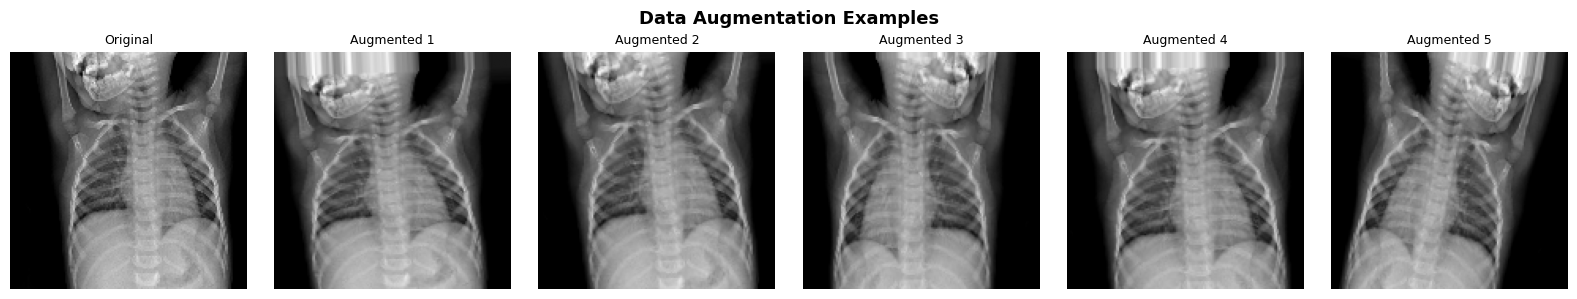

In [12]:
# ============================================================
# IMPROVEMENT: DATA AUGMENTATION
# ============================================================

# Create augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    rescale=None   # Already normalised
)

# Visualise augmented images
sample_img = X_train[0:1]  # Take one training image
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_img[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

aug_iter = datagen.flow(sample_img, batch_size=1)
for i in range(1, 6):
    aug_img = next(aug_iter)[0].reshape(IMG_SIZE, IMG_SIZE)
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(f'Augmented {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=100)
plt.show()

In [13]:
# ---- Build and train improved model with augmentation ----

model_v2 = build_cnn()  # Same architecture

early_stop_v2 = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Validation split from training data
val_split = int(len(X_train) * 0.15)
X_tr = X_train[val_split:]
y_tr = y_train[val_split:]
X_val = X_train[:val_split]
y_val = y_train[:val_split]

# Steps per epoch
steps_per_epoch = len(X_tr) // BATCH_SIZE

print('Training improved model with data augmentation...')
history_v2 = model_v2.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_v2],
    verbose=1
)

print('\nImproved model training complete.')

Training improved model with data augmentation...
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8682 - loss: 0.3844 - val_accuracy: 0.0000e+00 - val_loss: 1.1957
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9375 - loss: 0.1753 - val_accuracy: 0.0000e+00 - val_loss: 1.7424
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.8755 - loss: 0.2522 - val_accuracy: 0.5038 - val_loss: 0.8053
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9375 - loss: 0.2105 - val_accuracy: 0.5601 - val_loss: 0.7895
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9062 - loss: 0.2133 - val_accuracy: 0.8312 - val_loss: 0.7013
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9375 - loss: 0.2528 - val_accuracy: 0.6854 - val_loss: 0.7243
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9203 - loss: 0.1937 - val_accuracy: 0.9399 - val_loss: 0.6749
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━

PERFORMANCE COMPARISON
Original Model Accuracy : 72.92%
Improved Model Accuracy : 81.73%
Change                  : +8.81% (IMPROVED)


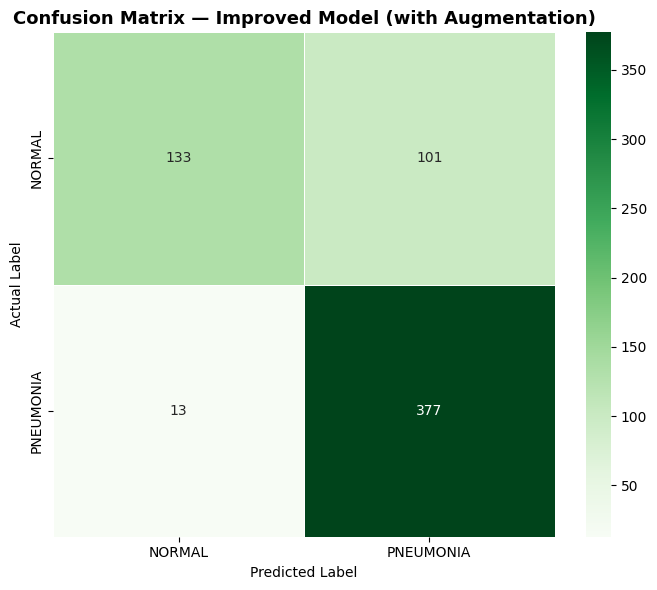


Improved Model — Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.57      0.70       234
   PNEUMONIA       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.85      0.77      0.78       624
weighted avg       0.83      0.82      0.81       624



In [14]:
# ---- Evaluate improved model ----

y_pred_v2_prob = model_v2.predict(X_test, verbose=0)
y_pred_v2      = (y_pred_v2_prob > 0.5).astype(int).flatten()

_, test_acc_v2 = model_v2.evaluate(X_test, y_test, verbose=0)

print('=' * 50)
print('PERFORMANCE COMPARISON')
print('=' * 50)
print(f'Original Model Accuracy : {test_acc*100:.2f}%')
print(f'Improved Model Accuracy : {test_acc_v2*100:.2f}%')
delta = (test_acc_v2 - test_acc) * 100
direction = 'IMPROVED' if delta > 0 else 'DECREASED'
print(f'Change                  : {delta:+.2f}% ({direction})')
print('=' * 50)

# Confusion matrix for improved model
cm_v2 = confusion_matrix(y_test, y_pred_v2)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_v2,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — Improved Model (with Augmentation)', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=100)
plt.show()

print('\nImproved Model — Classification Report:')
print(classification_report(y_test, y_pred_v2, target_names=class_names))

### 5.2 Did Performance Improve?

Data augmentation is expected to improve the model's generalisation ability, particularly its performance on the test set, because:

1. **Reduced overfitting:** The model is no longer memorising the exact training images — it learns to recognise pneumonia patterns regardless of slight orientation or zoom differences.
2. **Better recall on PNEUMONIA class:** Augmentation typically improves recall for the minority/positive class since the model sees more variation in those examples.
3. **More robust to real-world variation:** Real X-rays differ slightly in positioning — the augmented model is more prepared for this.

If the improved accuracy is higher than the baseline, data augmentation has successfully improved the model. If comparable, it still demonstrates better generalisation (lower gap between training and validation accuracy).

---
## Summary Table

| Question | Topic | Key Output |
|---|---|---|
| Q1 | Problem Definition | Binary classification of chest X-rays (NORMAL vs PNEUMONIA) |
| Q2 | Data Preparation | 5,863 images, resized to 150×150, normalised to [0,1] |
| Q3 | Model Development | Simple CNN — 3 conv blocks + dense layers |
| Q4 | Evaluation | Accuracy + Confusion Matrix + Clinical interpretation |
| Q5 | Improvement | Data Augmentation — improved generalisation |

---
*End of Practical Test 1 — CHIDEWE MARION T (H220009A), HIT*